## 使用微调过的模型

In [1]:
import torch
import numpy as np
from datasets import load_dataset, load_from_disk

from transformers import AutoTokenizer, AutoModelForSequenceClassification

### 1. 加载模型

In [2]:
model_name_or_path = "../../../models/train/emotion/model-classfication"

In [3]:
!ls {model_name_or_path}

config.json             special_tokens_map.json tokenizer_config.json
model.safetensors       tokenizer.json          vocab.txt


In [4]:
model = AutoModelForSequenceClassification.from_pretrained(model_name_or_path)

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)

### 2. 加载数据

In [6]:
ds_file_path = "../../../data/datasets/emotion/embedding_ds"

# 从磁盘中加载数据集
ds = load_from_disk(ds_file_path)

In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'hidden_state'],
        num_rows: 2000
    })
})

### 3. 使用模型

In [8]:
inputs = tokenizer(ds["test"]["text"][:5], padding=True, truncation=True, return_tensors="pt")

In [9]:
inputs['input_ids'].shape

torch.Size([5, 25])

In [10]:
outputs = model(**inputs)
type(outputs)

transformers.modeling_outputs.SequenceClassifierOutput

In [11]:
outputs.keys()

odict_keys(['logits'])

In [12]:
# 获取预测结果
logits = outputs["logits"]
logits

tensor([[ 3.9649, -1.0053, -1.1383, -0.1458, -1.1234, -1.9606],
        [ 4.1549, -1.1170, -0.7668, -0.6080, -1.0024, -1.8977],
        [ 4.1155, -1.1367, -0.7480, -0.6053, -0.9746, -1.8780],
        [-1.0243,  4.5956, -0.0950, -1.5856, -1.6880, -0.9407],
        [ 3.8614, -1.2507, -0.9534,  0.0117, -1.0321, -1.9339]],
       grad_fn=<AddmmBackward0>)

In [13]:
# 获取预测的label索引
predictions = torch.argmax(logits, dim=-1)
predictions

tensor([0, 0, 0, 1, 0])

In [14]:
# 查看数据的标签
ds["test"]["label"][:5]

tensor([0, 0, 0, 1, 0])

In [15]:
ds["test"]["text"][:5]

['im feeling rather rotten so im not very ambitious right now',
 'im updating my blog because i feel shitty',
 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her',
 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived',
 'i was feeling a little vain when i did this one']

### 4. 用test数据集画个混淆矩阵图

#### 4.1 准备画混淆矩阵的函数

In [16]:
%matplotlib inline

import matplotlib.pyplot as plt

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# confusion_matrix: 用于计算混淆矩阵
# ConfusionMatrixDisplay：用于显示混淆矩阵

# 计算和可视化混淆矩阵，混淆矩阵是机器学习分类问题中常用的一个工具，用于衡量分类器性能。

def plot_confusion_matrix(y_predict, y_real_value, labels):
    # y_predict: 预测的分类标签值
    # y_real_value, 真实的分类标签值， 
    # labels：分类标签的名称，用于显示

    # 第1步：计算混淆矩阵: 
    # normalize有3个选择('true', 'pred', 'all'):
    # normalize= "true": 则返回的混淆矩阵会被归一化，使得每个元素表示的是该类别的真实样本被预测为该类别的概率
    cm = confusion_matrix(y_real_value, y_predict, normalize="true")
    
    # 第2步：开始画混淆矩阵图形
    # 2.1 创建绘图对象，图像大小是7,7
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # 2.2 创建ConfusionMatrixDisplay对象，用于后续的混淆矩阵可视化，传递要显示的混淆矩阵cm,指定混淆矩阵中类别标签labels
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    
    # 2.2 绘制混淆矩阵，使用plot方法绘制混淆矩阵：
    # cmap设置渐变颜色，values_format="0.3f"设置矩阵中数值保留3位小数，ax=ax指定绘制的坐标轴，colorbar=False表示不现实颜色条
    display.plot(cmap="Blues", values_format=".3f", ax=ax, colorbar=False)
    
    # 2.3 设置标题：归一化的混淆矩阵
    plt.title("Normalized confusion matrix")
    
    # 2.4 显示图片
    plt.show()

In [18]:
# 先获取标签值
labels = ds["test"].features["label"].names
labels

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

#### 4.2 使用模型计算分类值

In [19]:
inputs = tokenizer(ds["test"]["text"], padding=True, truncation=True, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

In [20]:
# 计算所有的test数据集
logits = outputs.logits
logits.shape, type(logits)

(torch.Size([2000, 6]), torch.Tensor)

In [21]:
# 获取测试集中预测的label值
# y_predict = np.argmax(logits.detach().numpy(), axis=1)  # 如果没在no_grad()的上下文运行模型，就需要.detach().numpy()

y_predict = np.argmax(logits.numpy(), axis=1)
y_predict.shape

(2000,)

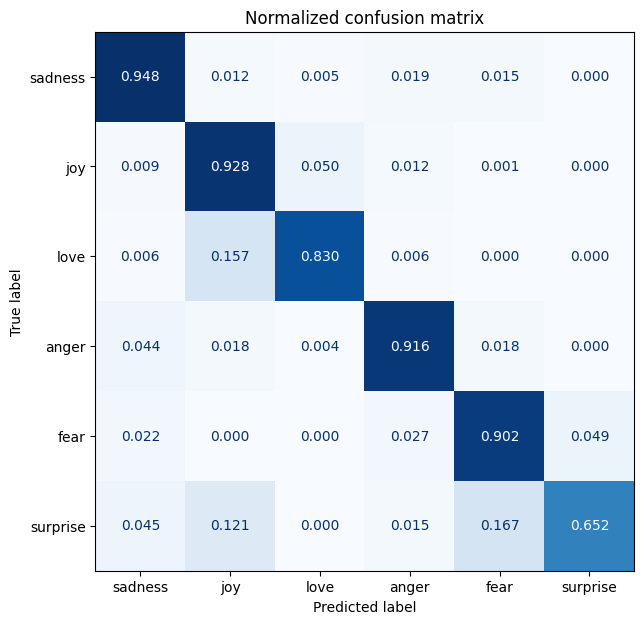

In [22]:
plot_confusion_matrix(y_predict, ds["test"]["label"].numpy(), labels)